## Week 6 Homework

---

### Q1: Let's start having some *real* fun...

We previously considered the normal-gamma specification

$$\scriptsize
\begin{align*}
p(\theta,\tau|x) &\propto{} p(\theta,\tau,x) = p(x|\theta)p(\theta)p(\tau) \quad (\theta \perp\!\!\perp \tau) \leftarrow \text{independent priors} & p(\theta|x,\theta_0,\tau_0, \tau) &={} \text{N}\left(\frac{\left(\tau_0 \theta_0+\tau\sum_{i=1}^{n}x_{i}\right)}{(\tau_0+n\tau)}, \sigma^{-2}=\tau_0+n\tau \right)\\
&={}  \left[\prod_{i=1}^n\sqrt{\frac{\tau}{2\pi}} e^{-\frac{\tau\left(x_i-\theta\right)^2}{2}}\right] \sqrt{\frac{\tau_0}{2\pi}} e^{-\frac{\tau_0\left(\theta-\theta_0\right)^2}{2}} \frac{\beta ^{\alpha}}{\Gamma(\alpha)} \tau^{\alpha -1}e^{-\beta \tau} & p(\tau|x, \alpha, \beta, \theta) &={} \text{Gamma}\left(\frac{\alpha}{2}+\frac{n}{2}, \frac{\beta}{2}+\frac{1}{2}\sum_{i=1}^n\left(x_i-\theta\right)^2 \right)\\{}\\
\end{align*}$$

How about instead we consider a "[location-scale-t](https://en.wikipedia.org/wiki/Student%27s_t-distribution#Location-scale_t-distribution)-norm-halfnorm-discrete-uniform" specification?

$$\large
\overset{x_i\; \sim\; \text{location-scale-t}(\mu, \sigma^2, \nu)}{\quad\quad\quad p(x|\mu,\sigma^2, \nu)} = {\prod_{i=1}^n
\frac{\Gamma\left(\frac{\nu+1}{2}\right)}{\Gamma\left(\frac{\nu}{2}\right) \sqrt{\pi \nu \sigma^2}}\left(1+\frac{1}{\nu} \frac{(x_i-\mu)^2}{\sigma^2}\right)^{-(\nu+1) / 2}}$$

$$\scriptsize
\begin{align}
p(\mu | \mu_0, \tau_0) &={} \sqrt{\frac{\tau_0}{2\pi}} e^{-\frac{\tau_0}{2}\left(\mu-\mu_0\right)^2} & p(\sigma^2 | \sigma_0^2) &={} \sqrt{\frac{2}{\pi\sigma_0^2}} \exp \left(-\frac{(\sigma^2)^2}{2 \sigma_0^2}\right) 1_{[0,\infty]}(\sigma^2) & p(\nu=i) &={} \Bigg\{ \begin{array}{cl} \frac{1}{100} & \text{for }i=1,\cdots,100\\ 0 & \text{otherwise} \end{array}\\
& \textrm{normal} && \textrm{half-normal} && \textrm{discrete uniform}
\end{align}
$$

Um yeah we're gonna need a Metropolis cleanup on aisles one two and three  
(or a slice or adapative squeeze rejection sampling steps... in place of Metroposlis steps)

*Implement the a Metropolis within Gibbs algorithm to smaple from the posterior of the above specification. Use a "smallish" sample size, say $n=100$ and implement your acceptance probability on a log-scale as described in [piazza post @65_f1](https://piazza.com/class/m5jvyco84083fm/post/65_f1)*


In [30]:
import numpy as np
import pymc as pm
import arviz as az

np.random.seed(424)
# Posterior of location-scale-t: arbitrarily pick all for now
mu_true = 3  # Location parameter
nu_true = 5  # df, controls tail heaviness.
sigma2_true = 4  # Scale parameter

# sample with n=100
n = 100
x_obs = np.random.standard_t(df=nu_true, size=n) * np.sqrt(sigma2_true) + mu_true

with pm.Model() as model:
    # Priors for mu, sigma^2, nu
    mu = pm.Normal("mu", mu=0, sigma=5) # pick a pretty broad prior centered at 0 but with var5
    sigma2 = pm.HalfNormal("sigma2", sigma=5)
    nu = pm.DiscreteUniform("nu", lower=1, upper=100)

    # likelihood
    likelihood = pm.StudentT("x", nu=nu, mu=mu, sigma=pm.math.sqrt(sigma2), observed=x_obs)

    # log-probability function for the model: scaling controls jump size
    step_mu = pm.Metropolis(vars=[mu])
    step_sigma2 = pm.Metropolis(vars=[sigma2])
    step_nu = pm.Metropolis(vars=[nu])  # discrete

    # MHwG sampling
    samples = pm.sample(5000, step=[step_mu, step_sigma2, step_nu], return_inferencedata=True)

az.summary(samples)



Output()

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu,2.969,0.256,2.480,3.432,0.007,0.005,1326.0,1439.0,1.0
nu,9.405,10.783,2.000,27.000,0.681,0.488,346.0,298.0,1.0
sigma2,4.755,1.231,2.565,6.917,0.059,0.042,436.0,898.0,1.0


### Q2: explore the role of sample size in providing inference for the degrees of freedom parameter $\nu$

*Implement the specification above using `PyMC` where you can explore inference on $\nu$ at different sample sizes. Provide a summarization and explanation of your findings.*


Output()

Output()

ERROR:pymc.stats.convergence:The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Output()

Output()

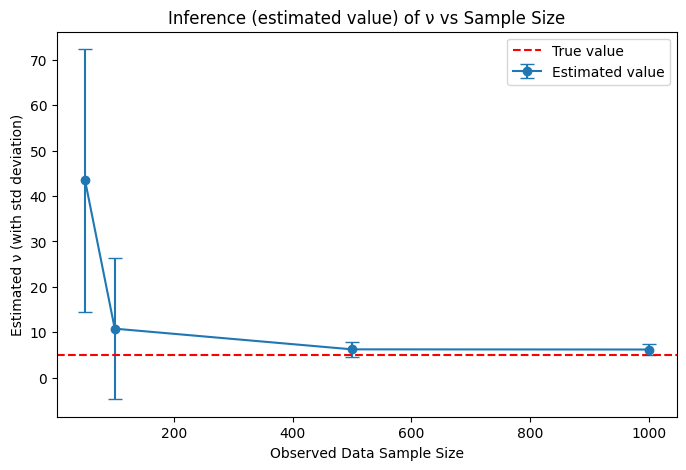

In [36]:
import numpy as np
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt

def run_sampling(n=100):
    np.random.seed(424)
    # Posterior of location-scale-t: arbitrarily pick all for now
    mu_true = 3  # Location parameter
    nu_true = 5  # df, controls tail heaviness.
    sigma2_true = 4  # Scale parameter

    x_obs = np.random.standard_t(df=nu_true, size=n) * np.sqrt(sigma2_true) + mu_true

    with pm.Model() as model:
        mu = pm.Normal("mu", mu=0, sigma=5)
        sigma2 = pm.HalfNormal("sigma2", sigma=5)
        nu = pm.DiscreteUniform("nu", lower=1, upper=100)
        likelihood = pm.StudentT("x", nu=nu, mu=mu, sigma=pm.math.sqrt(sigma2), observed=x_obs)
        step = [pm.Metropolis(vars=[mu]), pm.Metropolis(vars=[sigma2]), pm.Metropolis(vars=[nu])]
        samples = pm.sample(2500, step=step, return_inferencedata=True) #lowered draws for better runtime
    return samples

# Different sample sizes to test
sample_sizes = [50, 100, 500, 1000]
nu_means = []
nu_stds = []

# Run sampling for different sample sizes
for n in sample_sizes:
    trace = run_sampling(n)
    summary = az.summary(trace)
    nu_means.append(summary.loc["nu", "mean"])
    nu_stds.append(summary.loc["nu", "sd"])

# Plot inference results
plt.figure(figsize=(8, 5))
plt.errorbar(sample_sizes, nu_means, yerr=nu_stds, fmt='o-', capsize=5, label="Estimated value")
plt.axhline(y=5, color='r', linestyle='--', label="True value")
plt.xlabel("Observed Data Sample Size")
plt.ylabel("Estimated ν (with std deviation)")
plt.title("Inference (estimated value) of ν vs Sample Size")
plt.legend()
plt.show()

The graph shows how the estimated $ν$ changes with increasing sample size. The red dashed line represents the true value of $ν=5$, while the blue points and error bars represent the estimated values and their standard deviations. At smaller sample sizes, the estimates are highly uncertain, with large error bars and a large estimated value of $ν$, which makes sense as $ν$ is sampled from a uniform distribution between 1 and 100 (where the expected value is far from the true value of 5). Small datasets do not provide enough information to accurately infer the value of $ν$, so the posterior value is mostly affected by the prior. As the sample size increases to 500 and 1000, the estimates for $ν$ become more accurate and their uncertainty decreases, eventually stabilizing around the true value. Larger datasets allow for more reliable inference of the shape of the distribution of $ν$.

### Q3: the posterior predictive distribution does something like the following...

Let $p(\tau_i)$ be $\require{cancel} \textrm{gamma}\big(\tau_i | \alpha = \frac{\nu}{2}, \overset{\textrm{rate}\xcancel{\textrm{scale}}}{\beta = \frac{\nu}{2}}\big)$ and let $p(y_i|\tau_i)$ be $\textrm{N}(y_i | 0,\tau_i)$ and now integrate out the uncertainty in $\tau_i$ and see what distribution is left over for $y_i$.

*Go look at the gamma distribution and remember that you know that the integrals of unnormalized densities are the inverse of their normalizing constants. Then go look at the t distribution and determine what distribution the following expression defines. Then explain why the behavior demonstrated here is analagous to that of the posterior predictive distribution.*

$$\int p(y_i|\tau_i) p(\tau_i)  d\tau_i = \int \sqrt{\frac{\tau_i}{2\pi}}e^{-\frac{1}{2}\tau_i y_i^2} \frac {\frac{\nu}{2}^{\frac{\nu}{2}}}{\Gamma \left(\frac{\nu}{2}\right)} \tau_i^{\frac{\nu}{2}-1}e^{-\frac{\nu}{2}\tau_i} d\tau_i$$



We can rearrange the terms of the above equation:

$$\int p(y_i|\tau_i) p(\tau_i) d\tau_i = \frac{\left(\frac{\nu}{2} \right)^{\frac{\nu}{2}}}{\Gamma \left(\frac{\nu}{2} \right)} \sqrt{\frac{1}{2\pi}} \int \tau_i^{\frac{\nu}{2} - \frac{1}{2}} e^{-\left( \frac{\nu}{2} + \frac{y_i^2}{2} \right) \tau_i} d\tau_i$$

The remaining integral is the Gamma function,

$\int_0^\infty x^a e^{-bx} dx = \frac{\Gamma(a+1)}{b^{a+1}}, \quad \text{for } a > -1, b > 0$

with $a = \frac{\nu}{2} - \frac{1}{2}, \quad b = \frac{\nu}{2} + \frac{y_i^2}{2}$.

Substituting the gamma function for the integral gives us

$$\frac{\left(\frac{\nu}{2} \right)^{\frac{\nu}{2}}}{\Gamma \left(\frac{\nu}{2} \right)} \sqrt{\frac{1}{2\pi}} \cdot \frac{\Gamma \left(\frac{\nu+1}{2} \right)}{\left(\frac{\nu}{2} + \frac{y_i^2}{2} \right)^{\frac{\nu+1}{2}}}$$

which simplifies to:

$$\frac{\Gamma \left(\frac{\nu+1}{2} \right)}{\Gamma \left(\frac{\nu}{2} \right)} \frac{1}{\sqrt{\nu\pi}} \frac{1}{\left(1 + \frac{y_i^2}{\nu} \right)^{\frac{\nu+1}{2}}}$$

This is the density function of a Student (t-distribution): $y_i \sim t_{\nu}$

This derivation shows that when $\tau_i$ follows a gamma prior and $y_i$ is normally distributed given variance $\tau_i$, the marginal distribution of
$y_i$ follows a Student t-distribution. This implies that if we integrate out $\tau_i$, we get a t-distribution which has heavier tails (and thus greater variance) than a normal distribution. This aligns with the behavior of the posterior predictive distribution: since the posterior predictive distribution takes into account uncertainty of variance, it makes sense that it uses a t-distribution rather than a normal distribution, which is wider with more probability in the tails.